# Exploratory Data Analysis (EDA) Report

### Objective
The objective of this exploratory data analysis is to examine employee attrition patterns and identify the demographic, job-related, compensation, satisfaction, work-life balance, and career-related factors associated with employee turnover.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization style for the notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Loading the Dataset
df = pd.read_csv('HR_Employee_Attrition_Cleaned.csv')
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


In [4]:
# Data Integrity Check
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

print("\n--- Missing Values ---")
print(df.isnull().sum().sum(), "total missing values")

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum(), "duplicate rows found")

# Data types
print("\n--- Data Types ---")
df.info()

Dataset Shape: 1470 rows and 32 columns

--- Missing Values ---
0 total missing values

--- Duplicate Rows ---
0 duplicate rows found

--- Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   str  
 11  HourlyRate                1470 non-null   int64
 12  Job

Attrition Counts:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64

Overall Attrition Rate: 16.12%


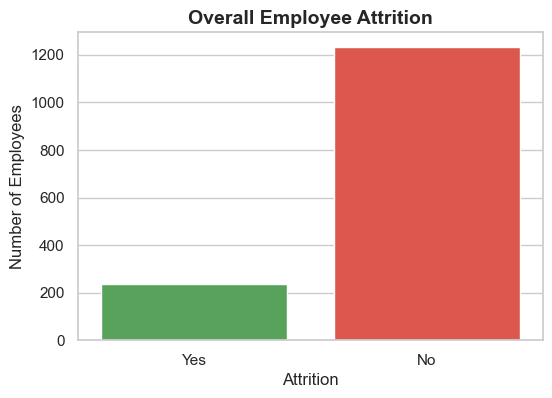

In [5]:
# Overall Attrition Rate Calculation
attrition_counts = df['Attrition'].value_counts()
print("Attrition Counts:\n", attrition_counts)

attrition_rate = (attrition_counts['Yes'] / len(df)) * 100
print(f"\nOverall Attrition Rate: {attrition_rate:.2f}%")

# Visualizing Overall Attrition
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Overall Employee Attrition', fontsize=14, fontweight='bold')
plt.ylabel('Number of Employees')
plt.show()

This stage establishes the baseline retention metric for the organization. The analysis reveals that 237 out of 1,470 employees departed, resulting in an overall attrition rate of 16.12%. This means roughly 1 in 6 employees are leaving, signaling a clear retention problem.

### Demographic Analysis

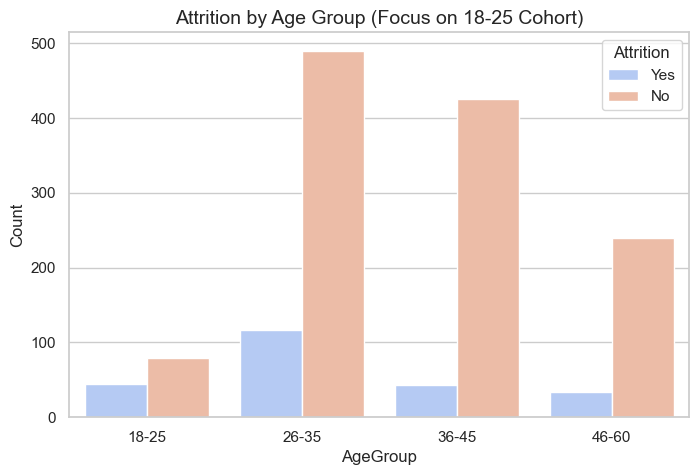

In [6]:
# Age Distribution and Attrition
# Creating age groups for easier analysis
bins = [17, 25, 35, 45, 60]
labels = ['18-25', '26-35', '36-45', '46-60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(8, 5))
sns.countplot(x='AgeGroup', hue='Attrition', data=df, palette='coolwarm')
plt.title('Attrition by Age Group (Focus on 18-25 Cohort)', fontsize=14)
plt.ylabel('Count')
plt.show()

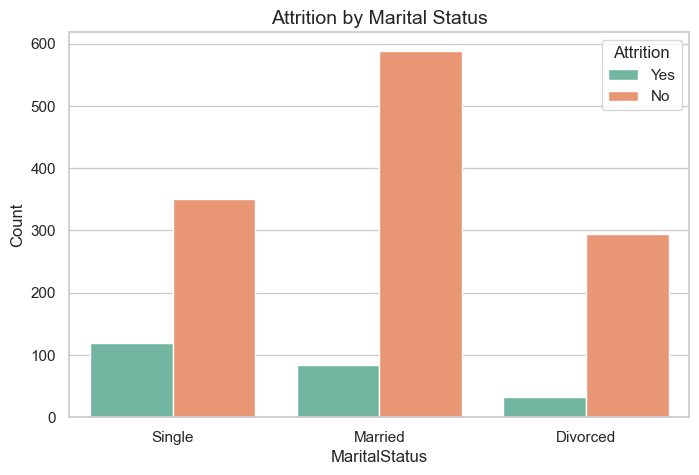

In [7]:
# Marital Status and Attrition
plt.figure(figsize=(8, 5))
sns.countplot(x='MaritalStatus', hue='Attrition', data=df, palette='Set2')
plt.title('Attrition by Marital Status', fontsize=14)
plt.ylabel('Count')
plt.show()

The data is sliced by demographic factors like age and marital status to see "who is leaving". The turnover is unevenly distributed: the youngest employees (18-25 years old) have an alarming attrition rate of nearly 36%, and single employees are quitting at twice the rate of married ones. This shows a struggle to retain early-career professionals.

### Departmental and Job-role Analysis

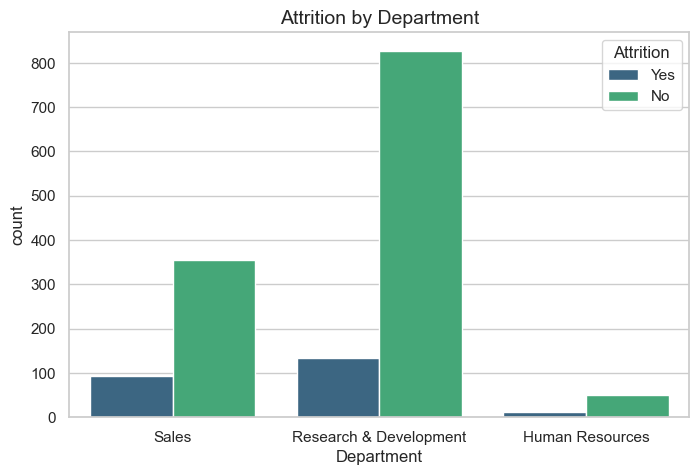

In [8]:
# Departmental Attrition
plt.figure(figsize=(8, 5))
sns.countplot(x='Department', hue='Attrition', data=df, palette='viridis')
plt.title('Attrition by Department', fontsize=14)
plt.show()

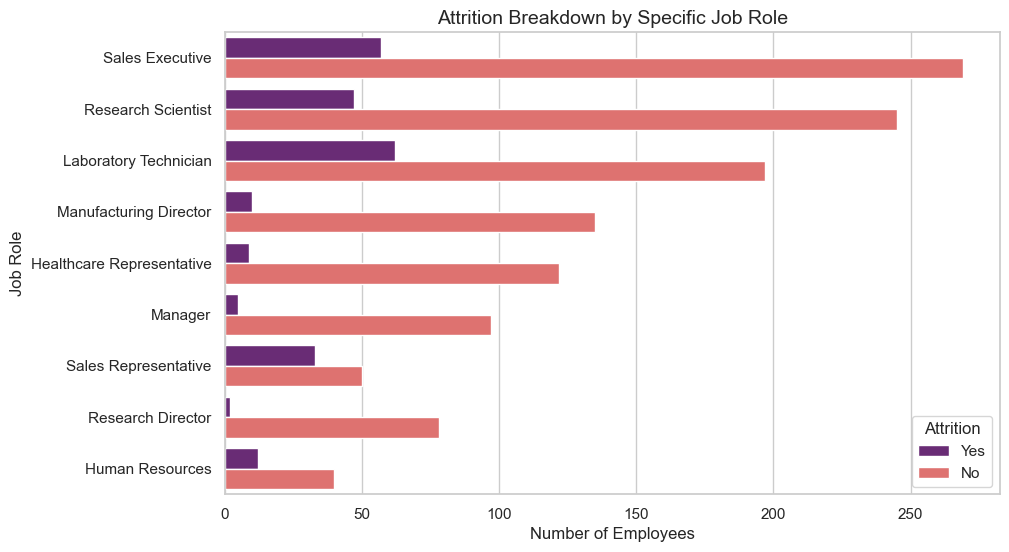

In [9]:
# The "Sales Representative" Crisis
plt.figure(figsize=(10, 6))
sns.countplot(y='JobRole', hue='Attrition', data=df, palette='magma', 
              order=df['JobRole'].value_counts().index)
plt.title('Attrition Breakdown by Specific Job Role', fontsize=14)
plt.xlabel('Number of Employees')
plt.ylabel('Job Role')
plt.show()

This stage maps out attrition across departments and specific roles to identify where the turnover is happening. The data highlights a critical operational weakness in the Sales department, with 'Sales Representatives' experiencing the highest turnover rate in the entire company. This is a major red flag as it directly impacts revenue generation.

### Compensation and Financial Indicators

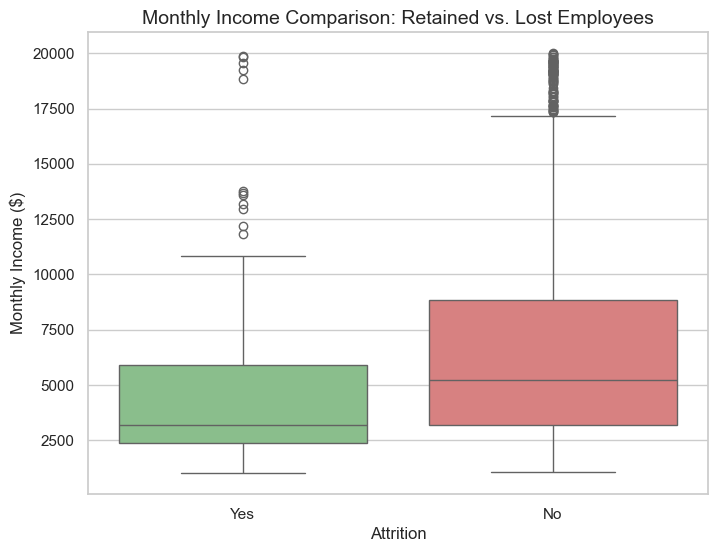

Median Income by Attrition Status:
Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64


In [10]:
# Monthly Income Disparities
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette=['#81C784', '#E57373'])
plt.title('Monthly Income Comparison: Retained vs. Lost Employees', fontsize=14)
plt.ylabel('Monthly Income ($)')
plt.show()

# Showing the median income for both groups
print("Median Income by Attrition Status:")
print(df.groupby('Attrition')['MonthlyIncome'].median())

To see if compensation is driving turnover, the median salaries of employees who stayed are compared against those who quit. The data shows a clear financial divide: departing employees have significantly lower median monthly incomes. This suggests that non-competitive base pay at lower-to-mid levels is a primary catalyst for turnover.

### Work Conditions

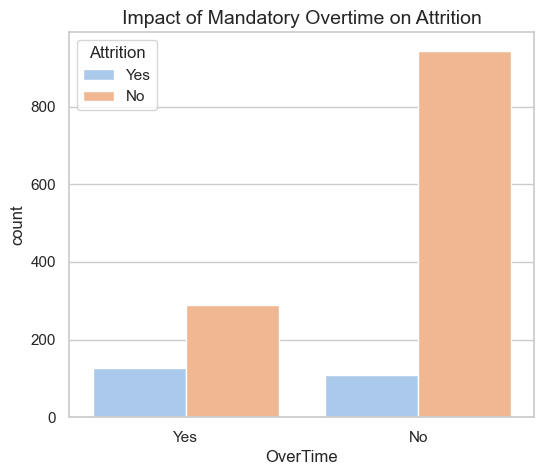

Attrition rate for employees working overtime: 30.53%


In [11]:
# The Overtime Burden
plt.figure(figsize=(6, 5))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='pastel')
plt.title('Impact of Mandatory Overtime on Attrition', fontsize=14)
plt.show()

# Calculating the specific overtime attrition rate
ot_yes = df[df['OverTime'] == 'Yes']
ot_attrition_rate = (ot_yes['Attrition'].value_counts()['Yes'] / len(ot_yes)) * 100
print(f"Attrition rate for employees working overtime: {ot_attrition_rate:.2f}%")

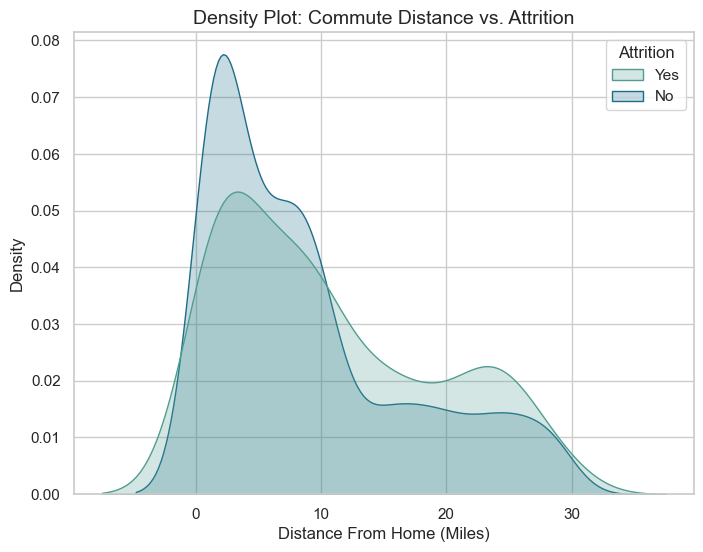

In [12]:
# The Commute Factor
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='DistanceFromHome', hue='Attrition', fill=True, common_norm=False, palette='crest')
plt.title('Density Plot: Commute Distance vs. Attrition', fontsize=14)
plt.xlabel('Distance From Home (Miles)')
plt.show()

This stage investigates daily workplace friction and burnout. Employees forced to work mandatory overtime are quitting at nearly three times the rate (30.5%) of those working standard hours. Furthermore, employees with longer daily commutes show a higher tendency to resign, proving that burnout and a lack of work-life balance are pushing people out.

### Multivariate and correlation analysis

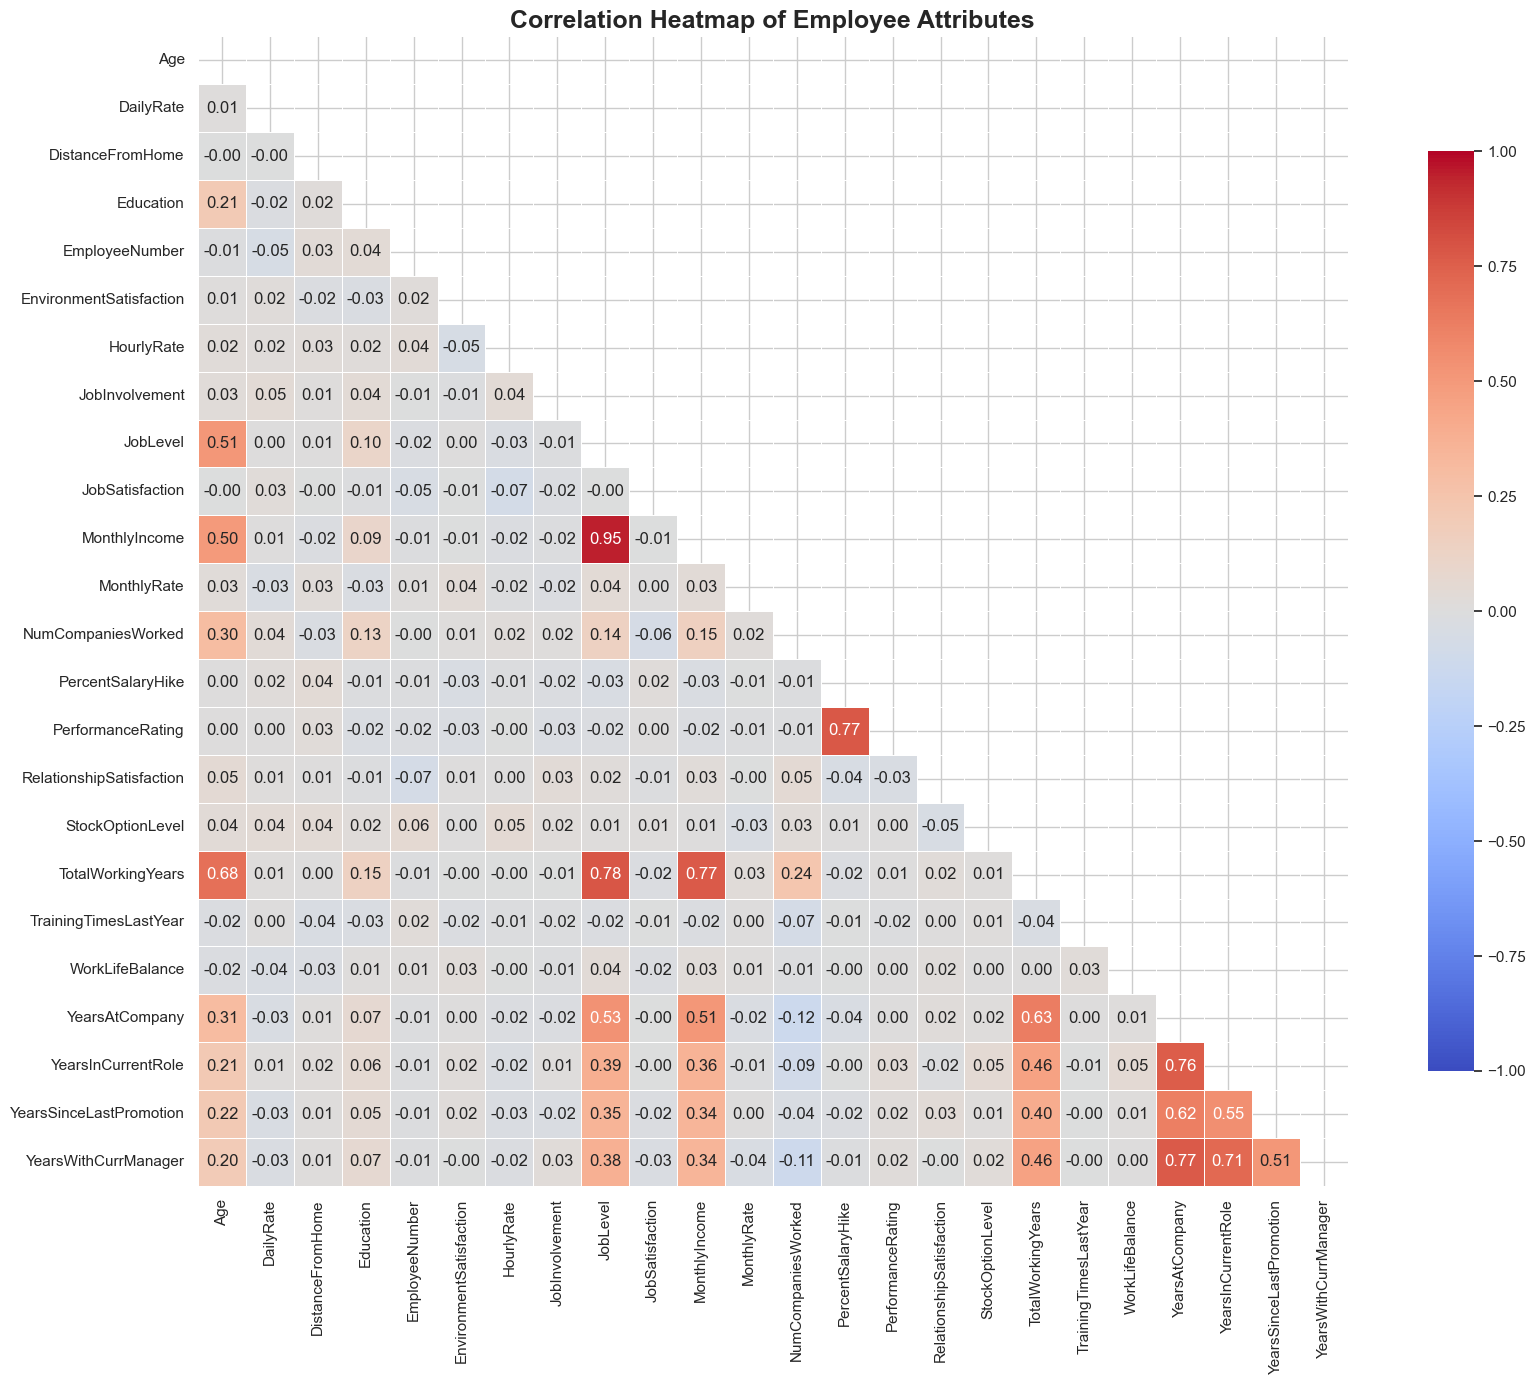

In [13]:
# Isolating the numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])

# Calculating correlation matrix
corr_matrix = numerical_df.corr()

# Ploting the heatmap
plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Mask upper triangle for cleaner look
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Employee Attributes', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

This final stage generates a mathematical 'heatmap' to connect all numerical variables and see how they influence one another. It confirms that financial growth in the company is strictly tied to tenure and job level. For younger employees seeking rapid career growth, this slow, tenure-based progression combined with long commutes and overtime is precisely what drives them to leave.

### Conclusion
The organizational turnover rate of 16.12% is driven by a highly specific intersection of variables: young, single employees working in Sales, earning lower wages, and being subjected to high overtime and long commutes. By transitioning away from generic HR policies and targeting these specific pain points—such as restructuring sales compensation, strictly limiting overtime, and providing flexible work arrangements for commuters—leadership can directly mitigate flight risks, preserve institutional knowledge, and build a highly resilient workforce

### Executive Business Insights & Recommendations

**1. The Flight Risk Profiles:**
* **Age & Tenure:** Attrition is heavily skewed towards younger employees (Age 18-25) and those in the early stages of their tenure (0-2 years at the company).
  **Recommendation:** Implement targeted 30-60-90 day onboarding check-ins and mentorship programs for new, younger hires to anchor them to the company culture.
* **Overtime Burnout:** Employees who work overtime show a drastically higher attrition rate (~30%) compared to those who do not (~10%).
  **Recommendation:** HR must audit department workloads. Overtime should be the exception, not the rule. Consider hiring additional headcount for chronically overworked departments like Sales.

**2. Financial & Role Factors:**
* **Income:** Those leaving the company have a significantly lower median monthly income than those staying. 
* **Sales Representatives:** This specific job role suffers the highest turnover rate of any group.
 **Recommendation:** Conduct an immediate compensation and commission structure review for Sales Representatives to ensure base pay and incentives are competitive with the current market.

**3. The Commute Factor:**
* Employees who live further away show slightly higher tendencies to leave the organization.
  **Recommendation:** Offer remote work flexibility or subsidized transit passes for employees commuting long distances to alleviate daily friction.